In [ ]:
import os
import tensorflow as tf
from tensorflow import keras


# PHASE 1: SETUP & VARIABLES
data_dir = r"Path-to-folder\Minor-project-DL-models\COVID-19_Radiography_Dataset"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 123 

# PHASE 2: DATA SPLITTING & LOADING

print("--- Loading Datasets ---")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    label_mode='categorical',
    color_mode='rgb',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_and_test_dataset)
validation_dataset = val_and_test_dataset.take(val_batches // 2)
test_dataset = val_and_test_dataset.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

--- Loading Datasets ---
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Found 21165 files belonging to 4 classes.
Using 4233 files for validation.


In [ ]:
# PHASE 3: DATA AUGMENTATION

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomBrightness(factor=0.2),
    keras.layers.RandomContrast(factor=0.2)
], name="medical_augmentation_pipeline")

print("\n--- Data Augmentation Pipeline Ready ---")


# PHASE 4: CLINICALLY ADJUSTED CLASS WEIGHTS

print("\n--- Calculating Class Weights ---")


covid_dir = os.path.join(data_dir, "covid-19")
lung_opacity_dir = os.path.join(data_dir, "lung_opacity")
normal_dir = os.path.join(data_dir, "normal")
pneumonia_dir = os.path.join(data_dir, "pneumonia")

covid_count = len(os.listdir(covid_dir))
lung_opacity_count = len(os.listdir(lung_opacity_dir))
normal_count = len(os.listdir(normal_dir))
pneumonia_count = len(os.listdir(pneumonia_dir))

total_images = covid_count + lung_opacity_count + normal_count + pneumonia_count
num_classes = 4

base_covid = (1 / covid_count) * (total_images / num_classes)
base_opacity = (1 / lung_opacity_count) * (total_images / num_classes)
base_normal = (1 / normal_count) * (total_images / num_classes)
base_pneumonia = (1 / pneumonia_count) * (total_images / num_classes)

class_weights = {
    0: base_covid,
    1: base_opacity,
    2: base_normal,
    3: base_pneumonia
}

print(f"Total Images Processed: {total_images}")
print("Final Class Weights Dictionary:", class_weights)
print("\n✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.")


--- Data Augmentation Pipeline Ready ---

--- Calculating Class Weights ---
Total Images Processed: 21165
Final Class Weights Dictionary: {0: 1.4632881637168142, 1: 0.8801147704590818, 2: 0.5191571821036107, 3: 3.934014869888476}

✅ PIPELINE COMPLETE. READY FOR MODEL ARCHITECTURE.


In [ ]:
import tensorflow as tf
from tensorflow import keras

# PHASE 11: THE MODEL BUILDER

print("\n--- Initializing Transfer Learning Architectures ---")

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
x = data_augmentation(inputs)

base_model = tf.keras.applications.EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)

base_model.trainable = False 

x = keras.layers.GlobalAveragePooling2D()(base_model.output)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.25)(x)
outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    
efficientnet_model = keras.Model(inputs, outputs, name="EfficientNetB0_Medical")

efficientnet_model.summary()



--- Initializing Transfer Learning Architectures ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "EfficientNetB0_Medical"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ medical_augmentati… │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ medical_augmenta… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ==========================================
# PHASE 12: SETTING UP CALLBACKS (The Safety Nets)
# ==========================================
# These tell the model to auto-save the best version and stop if it gets stuck.

def get_callbacks(model_name):
    # 1. Save the best model based on Validation AUC
    checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
    
    # 2. Stop training early if the model stops improving for 5 epochs
    early_stopping = EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    return [checkpoint, early_stopping]

print("\n--- Compiling Model ---")

efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print("\n=== Building and Training EfficientNetB0 ===")


efficientnet_callbacks = get_callbacks("EfficientNetB0")

EPOCHS = 30

history_efficientnet = efficientnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=efficientnet_callbacks
)

print("\n✅ PRE-TRAINED MODEL SUCCESSFULLY TRAINED AND SAVED.")


--- Compiling Model ---

=== Building and Training EfficientNetB0 ===
Epoch 1/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.7013 - auc: 0.8994 - loss: 0.6475
Epoch 1: val_auc improved from None to 0.94141, saving model to EfficientNetB0_best.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 240s 426ms/step - accuracy: 0.7550 - auc: 0.9323 - loss: 0.5258 - val_accuracy: 0.7718 - val_auc: 0.9414 - val_loss: 0.5724
Epoch 2/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8050 - auc: 0.9547 - loss: 0.4174
Epoch 2: val_auc did not improve from 0.94141
530/530 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.8061 - auc: 0.9555 - loss: 0.4117 - val_accuracy: 0.6989 - val_auc: 0.9185 - val_loss: 0.6929
Epoch 3/30
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8192 - auc: 0.9592 - loss: 0.3833
Epoch 3: val_auc improved from 0.94141 to 0.96303, saving model to EfficientNetB0_best.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 178s 335ms/step - accuracy: 0.8214 - auc: 0.9605 - loss: 0.3812 -


--- Step 1: Overall Testing Metrics ---

[ Evaluating EfficientNetB0 ]
67/67 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - accuracy: 0.8472 - auc: 0.9676 - loss: 0.4247
EfficientNet Accuracy: 84.72% | AUC: 0.9676

--- Step 2: Generating Predictions for  Model ---
Predictions successfully generated.

--- Step 3: The Confusion Matrix ---


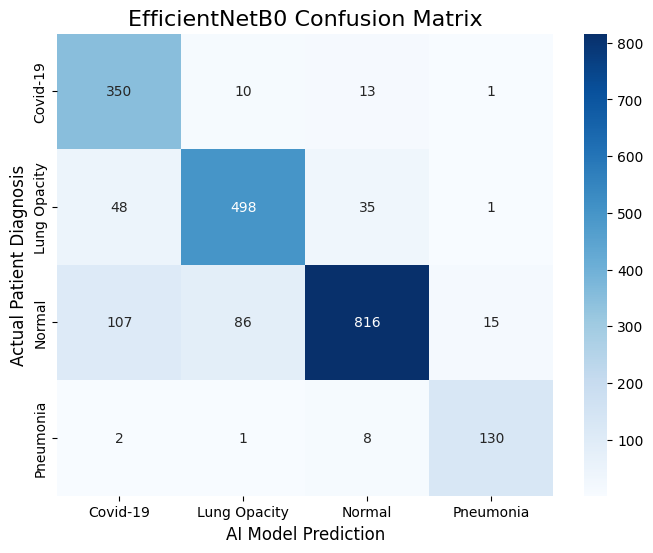


--- Step 4: Classification Report ---
              precision    recall  f1-score   support

    Covid-19       0.69      0.94      0.79       374
Lung Opacity       0.84      0.86      0.85       582
      Normal       0.94      0.80      0.86      1024
   Pneumonia       0.88      0.92      0.90       141

    accuracy                           0.85      2121
   macro avg       0.84      0.88      0.85      2121
weighted avg       0.86      0.85      0.85      2121



In [ ]:
# PHASE 7: EVALUATION & METRICS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- Step 1: Overall Testing Metrics ---")


print("\n[ Evaluating EfficientNetB0 ]")
eff_loss, eff_acc, eff_auc = efficientnet_model.evaluate(test_dataset)
print(f"EfficientNet Accuracy: {eff_acc * 100:.2f}% | AUC: {eff_auc:.4f}")


print("\n--- Step 2: Generating Predictions for  Model ---")

y_true = []
y_pred_probs_eff = []

for images, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))   
    y_pred_probs_eff.extend(efficientnet_model.predict(images, verbose=0))
       
y_pred_classes_eff = np.argmax(y_pred_probs_eff, axis=1)

print("Predictions successfully generated.")

# PHASE 8: VISUALIZING THE MISTAKES

print("\n--- Step 3: The Confusion Matrix ---")

class_names = ['Covid-19', 'Lung Opacity', 'Normal', 'Pneumonia']

cm = confusion_matrix(y_true, y_pred_classes_eff)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('EfficientNetB0 Confusion Matrix', fontsize=16)
plt.ylabel('Actual Patient Diagnosis', fontsize=12)
plt.xlabel('AI Model Prediction', fontsize=12)
plt.show()

# PHASE 9: THE CLINICAL REPORT

print("\n--- Step 4: Classification Report ---")

report = classification_report(y_true, y_pred_classes_eff, target_names=class_names)
print(report)

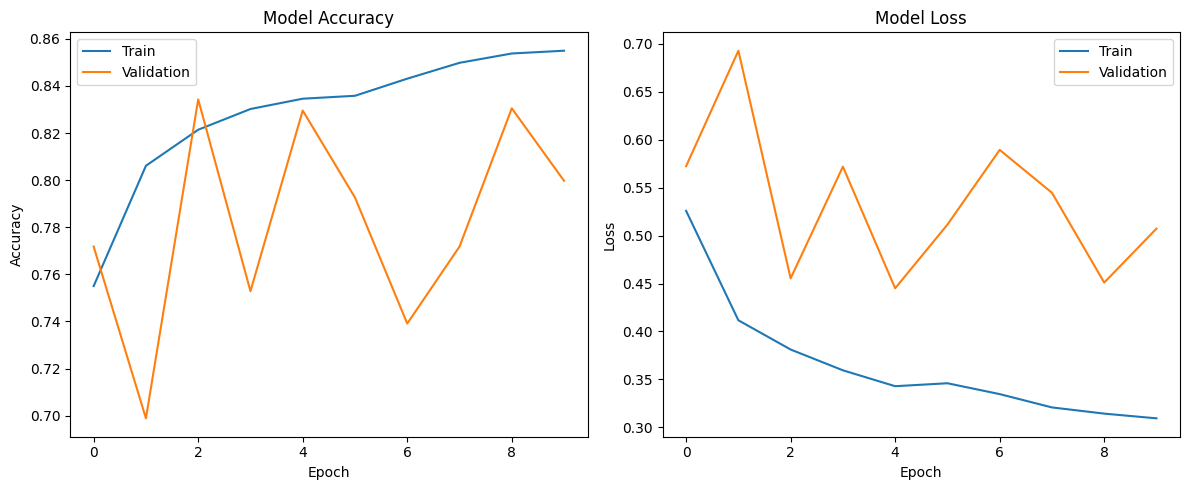

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_efficientnet.history['accuracy'])
plt.plot(history_efficientnet.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])


plt.subplot(1, 2, 2)
plt.plot(history_efficientnet.history['loss'])
plt.plot(history_efficientnet.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.tight_layout()
plt.show()

In [7]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

loaded_model = tf.keras.models.load_model("EfficientNetB0_best.keras")
print("Model loaded successfully!")

img_path = r"C:\Users\siddh\Documents\GitHub\Minor-project-DL-models\COVID-19_Radiography_Dataset\covid-19\COVID-58.png"
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 

predictions = loaded_model.predict(img_array)

class_names = ['Covid', 'Lung Opacity', 'Normal', 'Pneumonia']
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

print(f"Diagnosis: {class_names[predicted_class_index]}")
print(f"AI Confidence: {confidence:.2f}%")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Diagnosis: Covid
AI Confidence: 61.48%
